<img src='../../../common/DH_LOGO.jpeg' align='left' width=100%/>

In [1]:
# initial setup
#%run "../../../common/0_notebooks_base_setup.py"

# DHDSPaDM3A22 - Prática Guiada: Regressão Linear Múltipla.

# 1 **Introdução**

Regressão linear com preditores qualitativos.

1.Introdução ao dataset `bikeshare`. 
- Leitura de dados.
- Visualização de dados.

2.Regressão linear.
- Forma de regressão linear
- Construção de um modelo de regressão linear.
- Uso de modelos para previsão
- A escala dos recursos é importante?

3.Trabalhando com várias `features`.
- Visualização de dados.
- Adição de `features` ao modelo.

4.Escolha entre modelos
- Seleção de `features`.
- Métricas de avaliação para problemas de regressão.
- Comparação de modelos com conjuntos de treinamento / teste e RMSE.
- Comparando RMSE de teste com RMSE nulo (linha de base)
       
5.Criação de `features`
-  Gestão de `features` categóricas.
-  Feature Engineering.

**===========================================================================================**

### 1.1 Importando os dados

Vamos trabalhar com um conjunto de dados de aluguel de bicicletas que foi usado em um concurso Kaggle.

Os dados de aluguel por hora são fornecidos por dois anos. O conjunto de treinamento é composto pelos primeiros 19 dias de cada mês, enquanto o conjunto de teste é do dia 20 ao final do mês.

Queremos prever o número total de bicicletas alugadas durante cada hora coberta pelo conjunto de teste, usando apenas as informações disponíveis no conjunto de treinamento.

**CAMPOS DEL DATASET**

`datetime` - Dia e hora - timestamp

`season` -  Estação do ano: 1 = primavera, 2 = verão, 3 = outono, 4 = inverno

`holiday` - Feriado

`workingday` - Día da semana

`weather` - Clima:

              1: Clear, Few clouds, Partly cloudy, Partly cloudy
              2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
              3: Light Snow, Light Rain + Thunderstorm + Scattered clouds,
                 Light Rain + Scattered clouds
              4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 

`temp` - Temperatura em Celsius

`atemp` - Sensação térmica

`humidity` - Umidade

`windspeed` - Velocidade do vento

`casual` - Ususários não-registrados (number of non-registered user rentals initiated)

`registered` - Ususários registrados (number of registered user rentals initiated)

`count` - total de aluguéis

Lemos os dados e definimos a data e hora como um índice.

In [2]:
import pandas as pd

bikes = pd.read_csv('../Data/bikes.csv', 
                    index_col = 'datetime', 
                    parse_dates = True
                   )

In [3]:
type(bikes)

pandas.core.frame.DataFrame

In [4]:
bikes.shape

(10886, 11)

In [5]:
bikes.sample(10)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2012-02-12 17:00:00,1,0,0,1,7.38,7.575,37,27.9993,4,83,87
2012-01-05 14:00:00,1,0,1,1,13.94,15.910,39,19.0012,13,104,117
2012-10-02 20:00:00,4,0,1,3,25.42,27.275,94,8.9981,20,286,306
2012-04-09 20:00:00,2,0,1,1,20.50,24.240,36,30.0026,21,255,276
2012-08-18 09:00:00,3,0,0,1,27.06,31.060,65,19.0012,81,211,292
2011-09-14 01:00:00,3,0,1,1,25.42,29.545,78,6.0032,1,7,8
2012-12-11 12:00:00,4,0,1,2,14.76,15.910,53,30.0026,13,213,226
2011-01-03 14:00:00,1,0,1,1,10.66,12.120,30,19.0012,11,66,77
2012-08-13 08:00:00,3,0,1,2,29.52,33.335,51,6.0032,25,648,673


**Perguntas:**

- O que cada observação representa?
- Qual é a variável de resposta?
- Quantas variáveis existem?

Como `count` é um método da biblioteca pandas, é conveniente renomear a coluna:

In [6]:
bikes.rename(columns = {'count':'total'}, 
             inplace = True
            )

In [7]:
bikes.sample(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total
datetime,,,,,,,,,,,
2012-11-12 04:00:00,4,1,0,1,16.4,20.455,76,6.0032,1,3,4
2011-04-13 03:00:00,2,0,1,3,16.4,20.455,94,22.0028,0,2,2


### 1.2 Visualização

Definimos parâmetros globais para [`matplotlib`](https://matplotlib.org/).

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 16

Traçamos os pontos com a biblioteca [`pandas`](https://pandas.pydata.org/)

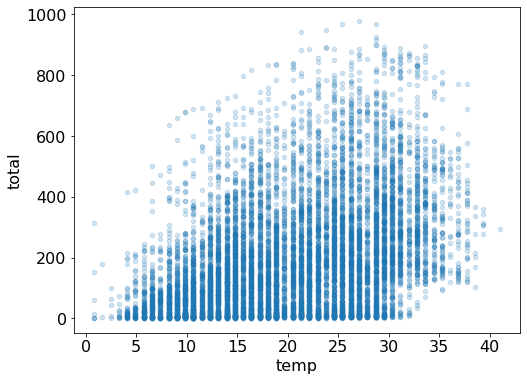

In [9]:
bikes.plot(kind = 'scatter', 
           x = 'temp', 
           y = 'total', 
           alpha = 0.2
          );

Ajustamos um modelo linear com [`seaborn`](https://seaborn.pydata.org/).

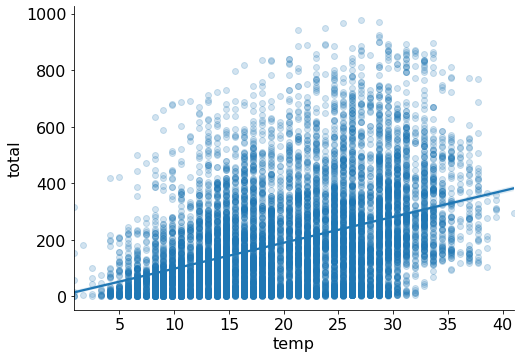

In [10]:
sns.lmplot(x = 'temp', 
           y = 'total', 
           data = bikes, 
           aspect = 1.45,
           scatter_kws = {'alpha': 0.2}
          );

# <span style="color:red">Parei aqui!</span>

# 2 Regressão Linear

## 2.1 Revisão: Forma do modelo linear

<img src='img/LINE_EQUATION.jpeg' align='center' width=40%/>

$$
y = \beta_{0} + \beta_{1} x_{1} + \beta_{2} x_{2} + \dots + \beta_{n }x_{n}
$$

<br>

- $y$ é a variável dependente.
- $\beta_{0}$ é o coeficiente linear, o interceptador do eix o $y$.
- $\beta_{1}$ é o coeficiente angular para $x_{1}$. 
- $\beta_{n}$ é o coeficiente angular para $x_{n}$.

Os $\beta$ são os Coeficientes do modelo.

- Esses valores são estimados (ou "aprendidos") durante o processo de adaptação do modelo usando o critério de  [mínimos quadrados](https://www.investopedia.com/terms/l/least-squares-method.asp).
- Especificamente, encontramos a linha (matematicamente) que minimiza a soma dos quadrados dos resíduos (ou "soma dos erros quadrados").
- E uma vez que tenhamos aprendido esses coeficientes, podemos usar o modelo para prever a resposta.

<img src='img/linear_regression.png' align='center' width=40%/>

## 2.2 Construindo o modelo de Regressão Linear

Vamos construir um modelo com [`Scikit-Learn`](https://scikit-learn.org/stable/) em cinco passos.

1. Prepare os dados em uma ** matriz de `featrures` e um vetor `target`.

2. Escolha uma classe de modelo importando a classe de estimador apropriada do Scikit-Learn.

3. Selecione os hiperparâmetros do modelo instanciando a classe com os valores desejados

4. Ajuste o modelo aos dados invocando o método `.fit()` da instância do modelo.

5. Aplique o modelo a novos dados:


Começamos com uma regressão linear simples!

In [11]:
# Criamos X e y

feature_cols = ['temp']
X = bikes[feature_cols]
y = bikes.total

In [12]:
type(y)

pandas.core.series.Series

In [13]:
X.shape

(10886, 1)

Importamos o pacote, instanciamos o estimador e ajustamos o modelo clássico com `sklearn`.

In [14]:
from sklearn.linear_model import LinearRegression

Instanciamos o modelo.

In [15]:
linreg = LinearRegression()

Treinamos o modelo.

In [16]:
linreg.fit(X, y)

LinearRegression()

Imprimimos coeficientes

In [17]:
print (linreg.intercept_)
print (linreg.coef_)

6.046212959616781
[9.17054048]


Interpretação do `intercept_` ($ \ beta_{0} $):

- É o valor esperado de $ y $ quando $ x = 0$.
- Portanto, é o número esperado de locações quando a temperatura é de $0$ graus Celsius.
- **Nota**:  Nem sempre faz sentido interpretar o `intercept_`. (Por quê?)

Interpretação do coeficiente `temp` ($ \beta_{1} $):

- É a variação $ \Delta y $ em $ y $ dividida pela variação $ \Delta x $ em $ x $, ou seja, a inclinação {slope} da linha de regressão.

- Assim, um aumento de temperatura de $1$ grau Celsius está associado a um aumento de $ 9.17 $ aluguel de bicicletas. 
$ \beta_{1} $ seria negativo se um aumento de temperatura estivesse associado a uma diminuição nos aluguéis.

## 2.3 Usando o modelo para prever

Quantos aluguel de bicicletas poderíamos prever se a temperatura fosse de $25$ graus Celsius?

In [18]:
# Aplicando a fórmula manualmente

test = 25

linreg.intercept_ + linreg.coef_ * test

array([235.309725])

In [19]:
# usando o método do objeto
import numpy as np

test_sklearn = np.array(test).reshape(-1, 1)

linreg.predict(test_sklearn)

array([235.309725])

## 2.4 A escala das features é importante?

Digamos que a temperatura foi medida em graus [Fahrenheit](https://www.vedantu.com/physics/relation-between-fahrenheit-and-celsius), em vez de Celsius. Como isso afeta o modelo?

In [20]:
# Criamos uma nova coluna para a temperatura em Fahrenheit
# ℃ = (℉ - 32)/1.8

bikes['temp_F'] = bikes.temp * 1.8 + 32
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,temp_F
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,49.712
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,48.236
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,48.236
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,49.712
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,49.712


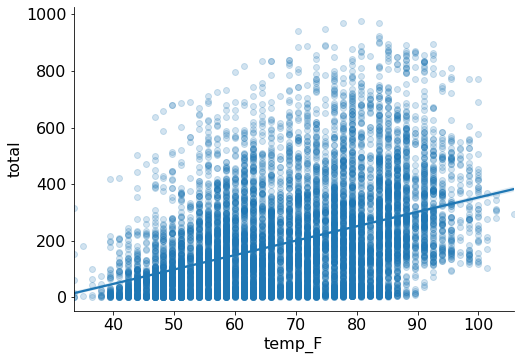

In [21]:
# Novamente ajustamos com Seaborn 
sns.lmplot(x = 'temp_F', 
           y = 'total', 
           data = bikes, 
           aspect = 1.45, 
           scatter_kws = {'alpha': 0.2}
          );

In [22]:
# criamos novamente X e y

feature_cols = ['temp_F']
X = bikes[feature_cols]
y = bikes.total

# Instanciamos o modelo e o ajustamos aos dados

linreg = LinearRegression()
linreg.fit(X, y)

# Imprimimos os coeficientes

print (linreg.intercept_)
print (linreg.coef_)

-156.98561782129445
[5.09474471]


In [23]:
# Convertemos 25°C a °F

test_en_f = 25 * 1.8 + 32
test_en_f

77.0

In [24]:
# Previsão para aluguéis a 77°F

test_sklearn_en_f = np.array(test_en_f).reshape(-1,1)

linreg.predict(test_sklearn_en_f)

array([235.309725])

**Conclusão**:  A escala das características é irrelevante para modelos de regressão linear. Mudando a escala, simplesmente mudamos nossa interpretação dos coeficientes.

In [25]:
# excluímos a coluna temp_F

bikes.drop('temp_F', 
           axis = 1, 
           inplace = True
          )

## 2.5 Visualização dos dados 2

In [26]:
# Exploramos mais features

feature_cols = ['temp', 'season', 'weather', 'humidity']

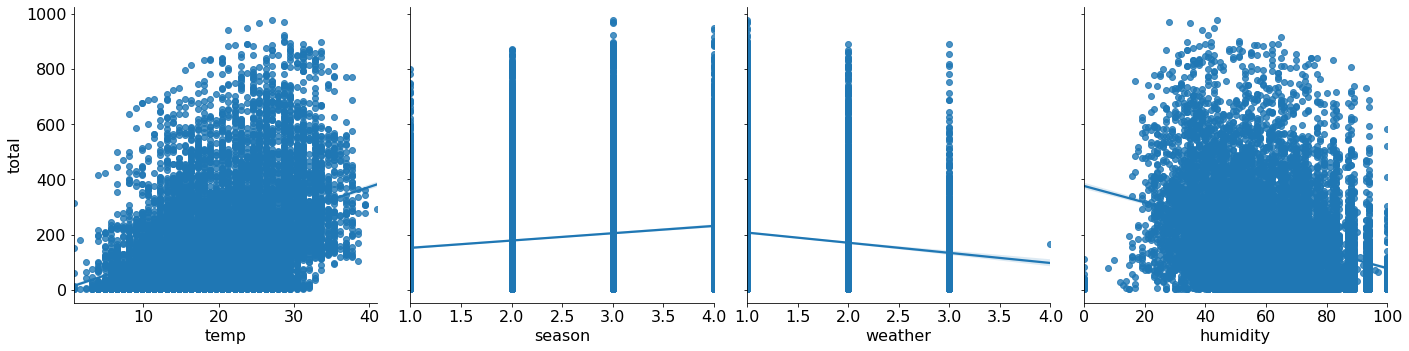

In [27]:
#  múltiplos gráficos em seaborn

sns.pairplot(bikes, 
             x_vars = feature_cols, 
             y_vars = 'total', 
             kind = 'reg',
             height = 5, 
             aspect = 1
            );

In [28]:
# matriz de correlação (intervalo de 1 a -1)

bikes.corr()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


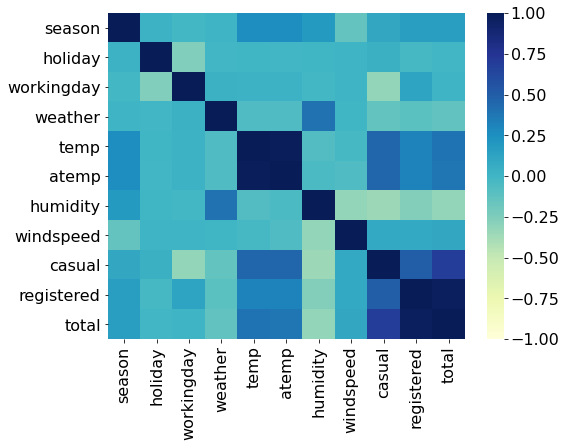

In [29]:
# visualizamos a matriz de correlação com Seaborn usando a heatmap

sns.heatmap(bikes.corr(), 
            vmin = -1, 
            vmax = 1, 
            center = 0, 
            cmap = "YlGnBu"
           );

Que relações são observadas?

## 2.6 Somando as features

In [30]:
# criamos uma lista de features

# feature_cols = ['temp', 'humidity']

In [31]:
# criamos novamente X and y
X = bikes[feature_cols]
y = bikes.total

# criamos o modelo e o ajustamos aos dados
linreg = LinearRegression()
linreg.fit(X, y)

# Imprimimos os coeficientes
print (linreg.intercept_)
print (linreg.coef_)

159.52068786129817
[ 7.86482499 22.53875753  6.67030204 -3.11887338]


In [32]:
## Para observá-lo melhor olhamos o nome com o coeficiente

list(zip(feature_cols, linreg.coef_))

[('temp', 7.864824992477439),
 ('season', 22.53875753246676),
 ('weather', 6.670302035923719),
 ('humidity', -3.118873382396501)]

# 3 Ecolhendo entre os modelos

## 3.1 Seleção de features

Como escolhemos quais recursos incluir no modelo? Vamos usar os conjuntos de treino e de teste (e eventualmente [validação cruzada](https://learn.g2.com/cross-validation)).

## 3.2 Métricas de avaliação para problemas de regressão

Existem três métricas de avaliação comuns para problemas de regressão:

**Mean Absolute Error (MAE)**: Média do valor absoluto dos erros:

$$ 
\fra{1}{n} \sum_{i = 1}^{n} |y_{i} - \hat{y}_{i}| 
$$

**Mean Squared Error (MSE)**: Media dos erros ao quadrado:

$$ 
\frac{1}{n} \sum_{i = 1}^{n}(y_{i} - \hat{y}_{i})^{2} 
$$

**Root Mean Squared Error (MSE)** Raíz qauadrada da media dos erros ao quadrado:

$$ 
\sqrt{\frac{1}{n} \sum_{i = 1}^{n}(y_{i} - \hat{y}_{i})^{2}} 
$$

In [33]:
# Exemplo de valores de respuesta verdadeiros e preditos
true = [10, 7, 5, 5, 10, 8, 8, 15, 12]
pred = [12, 8, 3, 4, 12, 9, 8, 12, 13]

In [34]:
from sklearn import metrics
import numpy as np
print ('MAE:', metrics.mean_absolute_error(true, pred))
print ('MSE:', metrics.mean_squared_error(true, pred))
print ('RMSE:', np.sqrt(metrics.mean_squared_error(true, pred)))
print ('R2:', metrics.r2_score(true, pred))

MAE: 1.4444444444444444
MSE: 2.7777777777777777
RMSE: 1.6666666666666667
R2: 0.7054973821989529


Comparando essas métricas:

- ** MAE ** é o erro absoluto médio.
- ** MSE ** "penaliza" grandes erros.
- ** RMSE ** é interpretável, possui as mesmas unidades do "y".
- **R2 ** é a proporção da variância total de $ Y $ explicada pelo modelo

Com exceção de R2, essas são todas [funções de perda](https://www.algorithmia.com/blog/introduction-to-loss-functions), porque queremos minimizá-las.

Exemplo adicional, para ver como o MSE/RMSE penaliza mais os maiores erros:

In [35]:
# com os mesmos valores de antes para true
true = [10, 7, 5, 5, 10, 8, 8, 15, 12]

# novo set de valores para a predição
pred = [12, 8, 3, 4, 12, 9, 8, 22, 13]

# MAE se incrementa levemente
print ('MAE:', metrics.mean_absolute_error(true, pred))

# MSE e RMSE são maiores do que antes. Por sua vez, R2 piora sua performance.
print ('MSE:', metrics.mean_squared_error(true, pred))
print ('RMSE:', np.sqrt(metrics.mean_squared_error(true, pred)))
print ('R2:', metrics.r2_score(true, pred))

MAE: 1.8888888888888888
MSE: 7.222222222222222
RMSE: 2.6874192494328497
R2: 0.23429319371727741


## 3.3 Comparando modelos usando sets de treino/teste e RMSE

### Train-Test Split

![Train-Test Split](img/train_test_split.png)

- [Train/Test Split, Cross-Validation, & You](https://medium.com/@hi.martinez/train-test-split-cross-validation-you-b87f662445e1)

In [36]:
# Definimos uma função que aceita uma lista de features, faz o split entre treino e teste,
# reservando 25% das observaciones para teste, e devolvendo o RMSE.

from sklearn.model_selection import train_test_split

def train_test_rmse(feature_cols):
    X = bikes[feature_cols]
    y = bikes.total
    # Como estamos trabalhando com observações ordenadas no tempo, podemos
    # usa shuffle = False para evitar data leakage
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle = False)
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)
    y_pred = linreg.predict(X_test)
    return np.sqrt(metrics.mean_squared_error(y_test, y_pred))

In [37]:
# comparamos diferentes ensembles de features
print (train_test_rmse(['temp', 'humidity']))
print (train_test_rmse(['temp', 'humidity','windspeed']))

209.76889183066913
209.76176410054472


In [38]:
# Usando features não permitidas!!!
# São as features que compoem a variável de resposta.
# Por definição a quantidade total de bikes emprestadas é a soma de bikes emprestadas a usuarios casuais e registrados
# Não há sentido criar um modelo dessas variáveis
# Mas como a relação é tão directa, as métricas de erro são baixíssimas.
print (train_test_rmse(['casual', 'registered']))

5.0547874484312994e-14


In [39]:
# Verificamos que as colunas são perfeitamente dependentes.
np.all(bikes.casual + bikes.registered == bikes.total)

True

# 4 Criando Features

## 4.1 Manipulando variáveis ​​categóricas

O Scikit-learn espera que todos os recursos sejam numéricos. Então, como incluímos um recurso categórico em nosso modelo?

- Categorias ordenadas: transforme-as em valores numéricos que representam essa ordem.

- Categorias não ordenadas: use codificação fictícia (0/1) (Variáveis-dummy).

Quais são as características categóricas do nosso conjunto de dados?

- Categorias ordenadas: clima (já codificado com valores numéricos representando a ordem).

- Categorias não ordenadas: estação (precisa de variáveis ​​dummy), feriado (já está codificado como dummy), dia útil (já está codificado como dummy).

Para a estação, não podemos simplesmente deixar a codificação como 1 = primavera, 2 = verão, 3 = outono e 4 = inverno, porque isso implicaria em um relacionamento ordenado. Em vez disso, criamos variáveis dummies:

In [40]:
# criamos variáveis dummies
season_dummies = pd.get_dummies(bikes.season, 
                                prefix = 'season'
                               )

# imprimimos cinco observações quaisquer
season_dummies.sample(n = 5, 
                      random_state = 1
                     )

,season_1,season_2,season_3,season_4
datetime,,,,
2011-09-05 11:00:00,0,0,1,0
2012-03-18 04:00:00,1,0,0,0
2012-10-14 17:00:00,0,0,0,1
2011-04-04 15:00:00,0,1,0,0
2012-12-11 02:00:00,0,0,0,1


Nota: O método `get_dummies` pode receber um dataframe inteiro, nesse caso não modifica as variáveis ​​numéricas e gera dummies para todas as categóricas que encontrar.

No entanto, realmente precisamos apenas de três variáveis fictícias (não quatro) e, portanto, vamos descartar a primeira variável fictícia. Por quê?

In [41]:
# Pulamos a primeira coluna
season_dummies.drop(season_dummies.columns[0], 
                    axis = 1, 
                    inplace = True
                   )

# imprimimos cinco observações quaisquer
season_dummies.sample(n = 5, 
                      random_state = 1
                     )

,season_2,season_3,season_4
datetime,,,
2011-09-05 11:00:00,0,1,0
2012-03-18 04:00:00,0,0,0
2012-10-14 17:00:00,0,0,1
2011-04-04 15:00:00,1,0,0
2012-12-11 02:00:00,0,0,1


Em geral, se você tem uma `feature` categórica com $k$ valores possíveis, você deve criar $ k - 1 $ variáveis fictícias.

In [42]:
# Concatenamos o DataFrame original e o dummy DataFrame (axis = 0 significa linhas, axis = 1 significa colunas)
bikes = pd.concat([bikes, season_dummies], 
                  axis = 1
                 )

# imprimimos cinco observações quaisquer
bikes.sample(n = 5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,season_2,season_3,season_4
datetime,,,,,,,,,,,,,,
2011-11-10 14:00:00,4,0,1,3,14.76,16.665,87,19.0012,6,58,64,0,0,1
2011-03-10 10:00:00,1,0,1,3,16.40,20.455,0,11.0014,0,17,17,0,0,0
2011-09-19 10:00:00,3,0,1,2,22.96,26.515,64,8.9981,21,84,105,0,1,0
2011-09-13 13:00:00,3,0,1,1,30.34,33.335,51,19.0012,48,136,184,0,1,0
2011-11-13 11:00:00,4,0,0,1,18.86,22.725,40,27.9993,108,187,295,0,0,1


In [43]:
# Incluímos variáveis dummies

feature_cols = ['temp', 'season_2', 'season_3', 'season_4', 'humidity']

X = bikes[feature_cols]
y = bikes.total
linreg = LinearRegression()
linreg.fit(X, y)


list(zip(feature_cols, linreg.coef_))

[('temp', 11.186405863575784),
 ('season_2', -3.3905430997179598),
 ('season_3', -41.73686071317068),
 ('season_4', 64.41596146824214),
 ('humidity', -2.819481636259646)]

Como interpretamos os coeficientes de estação? São medidos em relação à linha de base (mola):

- Mantendo todos os outros recursos fixos, o verão está associado a uma diminuição de 
$ 3.39 $ aluguel de bicicletas em relação à primavera.

- Mantendo todas as outras características fixas, a queda está associada a uma diminuição no aluguel de $ 41.73 $ bicicletas em relação à primavera.

- Mantendo todos os outros recursos fixos, o inverno está associado a um aumento de $64.4$ no aluguel de bicicletas em relação à primavera.

O que acontece se alterarmos a dummy que foi definida como linha de base? Os efeitos mudariam?

- Não, apenas mudaria nossa **interpretação** dos coeficientes.

**Importante**:  A codificação fictícia é relevante para todos os modelos de aprendizado de máquina, não apenas para modelos de regressão linear.

In [44]:
print (train_test_rmse(['temp', 'season_2', 'season_3', 'season_4', 'humidity']))

209.6725238915219


## 4.2 Conclusões: Comparação da regressão linear com outros modelos

Vantagens da regressão linear:

- Simples de explicar.
- Muito interpretável.
- O treinamento e a previsão do modelo são rápidos.
- É invariável a mudanças na escala dos recursos.
- Não pode ser estimado por mínimos quadrados se o número de features for maior que o número de observações.

Desvantagens da regressão linear:

- O desempenho é (geralmente) não competitivo com os melhores métodos de aprendizado supervisionado devido ao alto viés